MD**Intelligent Vision Systems · Lab 5 · Self-Driving Car Vision: Finding Lane Lines**  
Companion to **Lecture 5 (Part II) — Computer Vision for Self-Driving Cars**  
Dr. Muhammad Kazim · Department of Intelligent Systems, University of Lahore

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kazimbalti/intelligent-vision-systems/blob/main/LAB/Lab_5/04-hough-lines.ipynb) &nbsp; [Lecture 5 Part II slides](https://kazimbalti.github.io/intelligent-vision-systems/lectures/05_SDC_Lane_Finding.html#/the-hough-transform) &nbsp; [All Lab 5 notebooks](https://kazimbalti.github.io/intelligent-vision-systems/labs.html#lab-5-lane-lines)

# Lab 5D · Hough Transform: from Edges to Lines

_Lecture 5 Part II, Section 5: Hough Transform._

Canny gives us a cloud of edge **pixels**. The Hough transform (Paul Hough, 1962) groups pixels that lie on the same
**straight line** by letting every edge pixel **vote** for all the lines that could pass through it.

In [1]:
# Setup (only needed on Google Colab or a fresh environment).
# Uncomment the next line to install the packages this notebook uses:
# !pip install -q opencv-python numpy matplotlib

import os, urllib.request

# Fetch the lab images if they are not next to the notebook.
RAW = "https://raw.githubusercontent.com/Kazimbalti/intelligent-vision-systems/main/LAB/Lab_5"
for f in ['lab5_checks.py', 'exit-ramp.jpg']:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/{f}", f)
print("data ready")

data ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import lab5_checks as C   # auto-checks for this lab

MD## 1. Hough transform from scratch on a toy image

In polar form a line is `ρ = x·cosθ + y·sinθ` (`ρ` = distance from the origin, `θ` = angle). One point `(x, y)` gives a
**sinusoid** in (θ, ρ) space; points on the same line give sinusoids that **intersect** at that line's (θ, ρ).

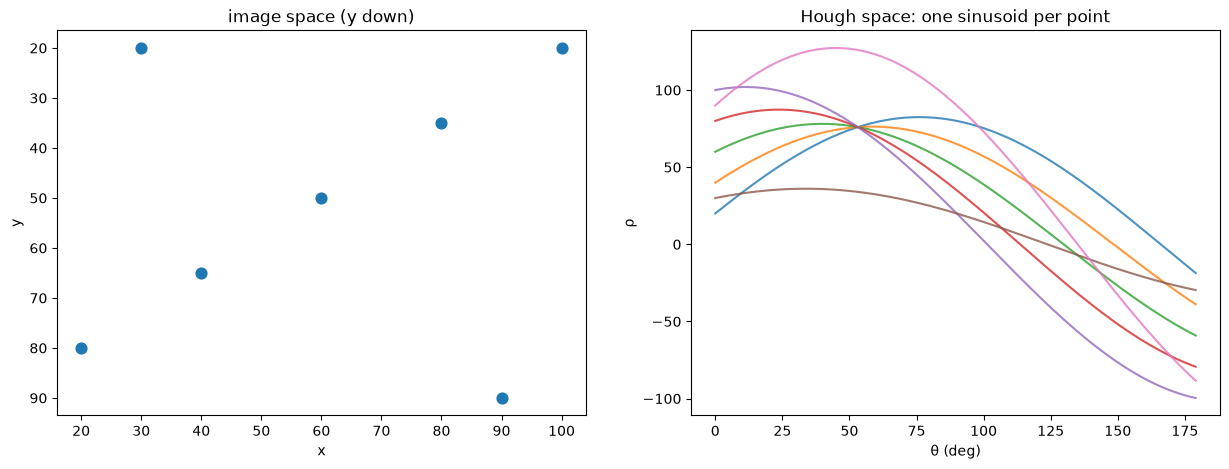

In [3]:
pts = np.array([[20, 80], [40, 65], [60, 50], [80, 35], [100, 20],   # 5 points on one line
                [30, 20], [90, 90]])                                   # 2 noise points
thetas = np.deg2rad(np.arange(0, 180))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(pts[:, 0], pts[:, 1], s=60); ax[0].invert_yaxis(); ax[0].set_title("image space (y down)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
for x, y in pts:
    ax[1].plot(np.rad2deg(thetas), x * np.cos(thetas) + y * np.sin(thetas), alpha=0.8)
ax[1].set_xlabel("θ (deg)"); ax[1].set_ylabel("ρ"); ax[1].set_title("Hough space: one sinusoid per point")
plt.show()

MDNow **discretise** (θ, ρ) into a grid (the *accumulator*) and count votes. The cell with the most votes is the line.

best line: theta = 53 deg, rho = 76, votes = 5


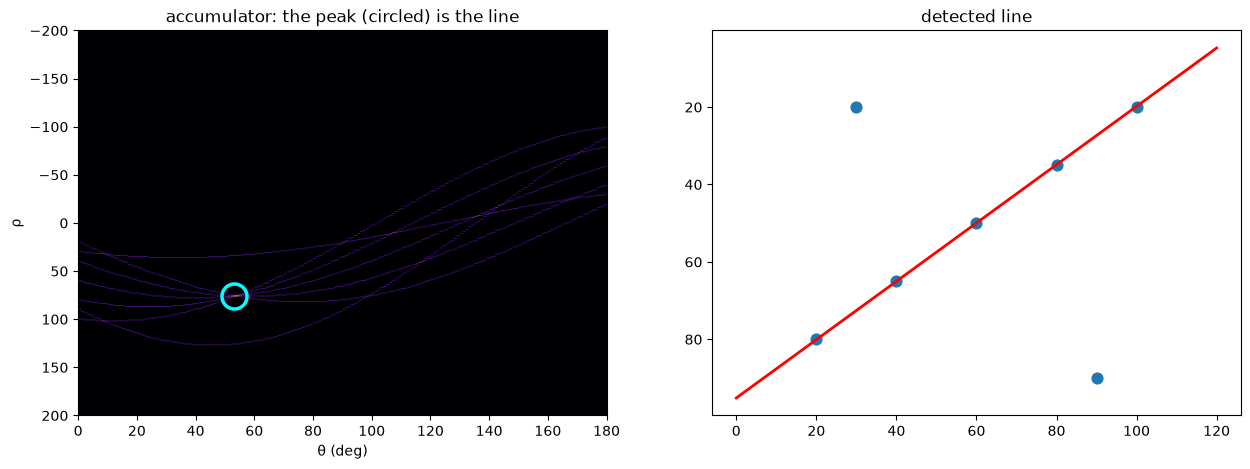

In [4]:
def hough_accumulator(points, rho_res=1, theta_res_deg=1, max_rho=200):
    thetas = np.deg2rad(np.arange(0, 180, theta_res_deg))
    rhos = np.arange(-max_rho, max_rho + 1, rho_res)
    acc = np.zeros((len(rhos), len(thetas)), dtype=int)
    for x, y in points:
        r = x * np.cos(thetas) + y * np.sin(thetas)
        acc[np.round((r + max_rho) / rho_res).astype(int), np.arange(len(thetas))] += 1
    return acc, rhos, thetas

acc, rhos, ths = hough_accumulator(pts)
r_i, t_i = np.unravel_index(acc.argmax(), acc.shape)
rho, theta = rhos[r_i], ths[t_i]
print(f"best line: theta = {np.rad2deg(theta):.0f} deg, rho = {rho}, votes = {acc.max()}")

xs = np.array([0, 120]); ys = (rho - xs * np.cos(theta)) / np.sin(theta)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(acc, aspect="auto", cmap="magma", extent=[0, 180, rhos[-1], rhos[0]]); ax[0].set_xlabel("θ (deg)"); ax[0].set_ylabel("ρ")
ax[0].plot(np.rad2deg(theta), rho, "o", ms=18, mfc="none", mec="cyan", mew=2.5)
ax[0].set_title("accumulator: the peak (circled) is the line")
ax[1].scatter(pts[:, 0], pts[:, 1], s=60); ax[1].plot(xs, ys, "r-", lw=2); ax[1].invert_yaxis(); ax[1].set_title("detected line")
plt.show()

MD## 2. Probabilistic Hough with OpenCV: `cv2.HoughLinesP`

```python
lines = cv2.HoughLinesP(edges, rho, theta, threshold, minLineLength=..., maxLineGap=...)
```

| parameter | meaning | sensible start |
|---|---|---|
| `rho` | distance resolution of the grid (pixels) | 1–2 |
| `theta` | angular resolution (radians) | `np.pi/180` (1°) |
| `threshold` | minimum votes for a line | 10–30 |
| `minLineLength` | shortest segment accepted (pixels) | 20–50 |
| `maxLineGap` | largest gap joined into one segment (pixels) | 5–30 |

It returns an array of segment end-points `(x1, y1, x2, y2)` — or **`None`** if nothing is found, so always check!

segments found: 211


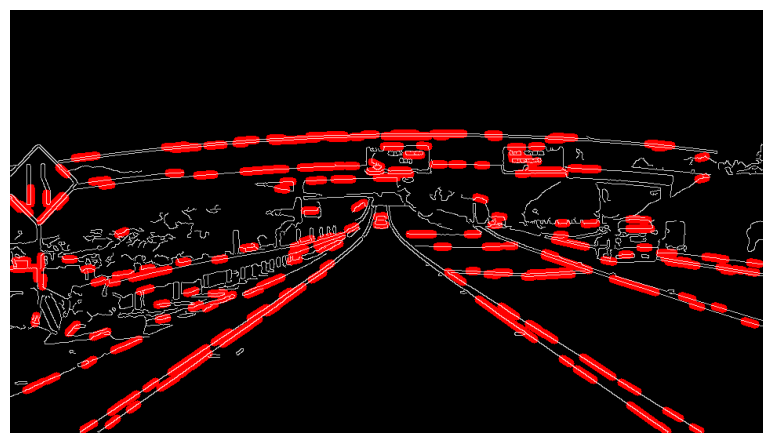

In [5]:
image = mpimg.imread("exit-ramp.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blur_gray = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur_gray, 50, 150)

def draw_segments(image, lines, color=(255, 0, 0), thickness=10):
    line_image = np.zeros_like(image)                      # blank to draw on
    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            cv2.line(line_image, (int(x1), int(y1)), (int(x2), int(y2)), color, thickness)
    return line_image

# Parameters from the lesson: far too permissive
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=1, minLineLength=10, maxLineGap=1)
color_edges = np.dstack((edges, edges, edges))
combo = cv2.addWeighted(color_edges, 0.8, draw_segments(image, lines), 1, 0)
print("segments found:", 0 if lines is None else len(lines))
plt.figure(figsize=(10, 5.5)); plt.imshow(combo); plt.axis("off"); plt.show()

MD## 3. Quiz — region mask + Hough parameters

Add a **quadrilateral** region of interest with `cv2.fillPoly` and tune the Hough parameters until only the lane lines remain.

<details><summary><b>Show the answer</b> (try first!)</summary>

Canny `(50, 150)`; vertices `[(0, h), (450, 290), (490, 290), (w, h)]`; `rho = 2`, `theta = np.pi/180`,
`threshold = 15`, `min_line_length = 40`, `max_line_gap = 20`. This picks up the lane lines and nothing else.
</details>

segments found: 37


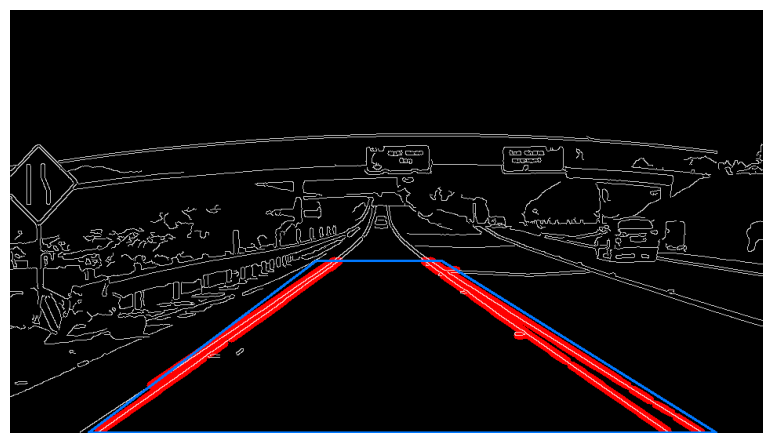

In [6]:
# Region of interest: a four-sided polygon
mask = np.zeros_like(edges)
imshape = image.shape
vertices = np.array([[(390, 320), (550, 320), (900, 539), (100, 539)]], dtype=np.int32)   # MODIFY
cv2.fillPoly(mask, vertices, 255)
masked_edges = cv2.bitwise_and(edges, mask)

# Hough parameters - MODIFY
rho = 1                 # distance resolution in pixels of the Hough grid
theta = np.pi / 180     # angular resolution in radians of the Hough grid
threshold = 1           # minimum number of votes (intersections in Hough grid cell)
min_line_length = 10    # minimum number of pixels making up a line
max_line_gap = 3        # maximum gap in pixels between connectable line segments

lines = cv2.HoughLinesP(masked_edges, rho, theta, threshold,
                        minLineLength=min_line_length, maxLineGap=max_line_gap)
lines_edges = cv2.addWeighted(color_edges, 0.8, draw_segments(image, lines), 1, 0)
cv2.polylines(lines_edges, vertices, True, (0, 120, 255), 2)
print("segments found:", 0 if lines is None else len(lines))
plt.figure(figsize=(10, 5.5)); plt.imshow(lines_edges); plt.axis("off"); plt.show()

MD### ✅ Auto-check
Run the cell below after every change. It prints ✅ when your result is good, or a 💡 hint — never the answer.

In [7]:
C.check_hough(lines)

   37 segments: 14 on the left lane, 23 on the right lane, 0 elsewhere
💡 Lots of tiny duplicate segments. Raise threshold and min_line_length, allow a bigger max_line_gap.


False

MD## Your turn — Lab 5D tasks

1. Report your final ROI vertices and Hough parameters and show the result. How many segments do you get?
2. Change **one parameter at a time** (`threshold`, `minLineLength`, `maxLineGap`) and describe what each one does to the output.
3. Extend the from-scratch accumulator in Section 1 to the real `masked_edges` image (use `np.nonzero` to get edge pixels).
   Plot the accumulator and mark the **two strongest peaks** — they are the two lane lines. What are their θ values?

**Deliverable:** keep this notebook with your code, outputs and a short written answer to each task.